# Introduction to Deep Learning

Contrairement au Machine Learning classique qui nécessite une extraction de caractéristiques humaine ("Human in the Loop"), le Deep Learning réalise l'extraction de caractéristiques et l'apprentissage de manière intégrée et automatique ("End-to-end learning").  
Le réseau est une composition de fonctions simples ($f=f_{1}\circ f_{2}\circ\dots\circ f_{L}$) organisés en layers.  
Une **couche** est composée de neurones.
- Input layer: reçoit les données brutes
- Hidden layers: grand nombre de layers qui transforment chacune l'information. PLus le réseau est profond et plus il peut captuer des concepts abstraits.
- Output layer: renvoie le résultat final

Rôle d'un neurone:
- Réception et Pondération : Le neurone reçoit des valeurs d'entrée ($x_1, x_2, \dots, x_n$) et affecte à chacune un poids ($w_1, w_2, \dots, w_n$) représentant son importance.
- Somme pondérée : Il calcule la somme de ces signaux pondérés, souvent augmentée d'un "biais" ($b$) : $w^{\top}x+b$.
- Activation : Ce total est passé à une fonction d'activation ($\varphi$) non linéaire (comme ReLU, Sigmoïde ou Tanh) qui transforme le résultat en un signal de sortie.
  
La Largeur (neurones d'une même couche): permet d'analyser une multitude de détails en parallèle.
La Profondeur (succession de couches): Elle permet de combiner des détails simples (bords, textures) pour comprendre des objets complexes.

Pour que ces neurones deviennent efficaces, le réseau utilise l'algorithme de rétropropagation qui repart de l'erreur et remonte à travers toutes les couches pour identifier quels neurones se sont trompés. Un optimiseur (comme Adam ou SGD) ajuste alors les poids de chaque neurone. On diminue l'importance (le poids) des neurones qui ont causé l'erreur et on augmente celle de ceux qui ont bien prédit.
On répète cette opération des milliers de fois avec des exemples différents. À force de s'ajuster, le réseau finit par "comprendre" de lui-même les caractéristiques importantes.

In [1]:
import numpy as np
import pandas as pd
datatrain = pd.read_csv("DataMixtures/mixtureexampleTrain.csv", delimiter = "\t", header=
None)
print(f"datatrain.shape: {datatrain.shape}")
# index 2 => 3e colonne
# .values: conversion en tableau numpy pour le réseau de neurones
Ytrain = datatrain[2].values
# toutes les valeurs négatives sont étiquettées par 0 pour préparer la classification binaire
Ytrain[Ytrain < 0] = 0
# suppression de la colonne des labels
Xtrain = datatrain.drop(2, axis=1).values
unique, counts = np.unique(Ytrain, return_counts=True)
for u, c in zip(unique, counts):
    print(f"classe {u}: {c} valeurs")
if len(unique) == 2:
    print("Il s'agit d'un problème de classification binaire")

datatrain.shape: (1759, 3)
classe 0.0: 820 valeurs
classe 1.0: 939 valeurs
Il s'agit d'un problème de classification binaire


In [2]:
datatrain2 = pd.read_csv("DataMixtures/mixtureexampleTest.csv", delimiter = "\t", header=
None)
print(f"datatrain.shape: {datatrain2.shape}")
Ytrain2 = datatrain2[2].values
Ytrain2[Ytrain2 < 0] = 0
Xtrain2 = datatrain2.drop(2, axis=1).values
unique, counts = np.unique(Ytrain2, return_counts=True)
for u, c in zip(unique, counts):
    print(f"classe {u}: {c} valeurs")
if len(unique) == 2:
    print("Il s'agit d'un problème de classification binaire")

datatrain.shape: (5272, 3)
classe 0.0: 2457 valeurs
classe 1.0: 2815 valeurs
Il s'agit d'un problème de classification binaire


In [3]:
# import tensorflow as tf
# print(tf.__version__)
# import keras
# keras.__version__

MLP: Perceptron Multicouche: type de modèle de Deep Learning et architecture spécifique de réseau de neurones artificiels à propagation avant, composé d'au moins trois couches: une couche d'entrée, une ou plusieurs couches cachées et une couche de sortie, chaque couche étant entièrement connectée à la suivante.

Les fonctions d'activation introduisent la non-linéarité indispensable pour que le réseau puisse apprendre des relations complexes entre les entrées et les sorties:

* **Identité :** $\varphi(z) = z$
* **Heaviside :** $\varphi(z) = \begin{cases} 0 & \text{si } z < 0 \\ 1 & \text{sinon} \end{cases}$
* **Sigmoïde :** $\varphi(z) = \frac{1}{1 + e^{-z}}$
* **Tangente hyperbolique (tanh) :** $\varphi(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} = \frac{e^{2z} - 1}{e^{2z} + 1}$ 
* **ReLU (Rectified Linear Unit) :** $\varphi(z) = \max(0, z)$

Pour que le réseau devienne efficace, il doit ajuster ses poids grâce à un processus itératif basé sur les données $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^N$.

Mise à jour les paramètres du réseau :
1. **Forward pass** : Le réseau fait une prédiction.
2. **Calcul de l'erreur** : On mesure l'écart entre la prédiction et la réalité via une fonction de perte $J(W)$.
3. **Backward pass** : On remonte le réseau pour calculer le gradient de l'erreur par rapport à chaque poids $\nabla_{W} J$.

L'optimiseur utilise les gradients pour modifier les poids $W$ afin de réduire l'erreur :
* **SGD (Stochastique Gradient Descent)** : Met à jour les poids après chaque échantillon ou mini-batch.
* **RMSProp** : Utilise une moyenne pondérée des carrés des gradients pour adapter le taux d'apprentissage.
* **Adam** : Combine les avantages du **Momentum** et de **RMSProp** ; c'est l'optimiseur le plus utilisé actuellement.

$$W_{l}^{t+1} \leftarrow W_{l}^{t} - \eta \nabla_{W_{l}} J(W_{l}^{t})$$

Où $\eta$ représente le **taux d'apprentissage** (learning rate).

In [4]:
from keras.models import Sequential
from keras.layers import Dense, Activation, InputLayer

# hidden layer de largeur 64 => couche de 64 neurones en parallèle 
nhu = 64
# dimension de l'input layer => le réseau attend 2 valeurs en entrées 
input_shape=(2, )
# modèle de type séquentiel => l'information circule linéairement d'une couche à la suivante
# Dense(units=nhu, activation="relu": hidden layer, chaque neurone est connectées à  tous les neurones précédents
# fonction d'activation ReLu
# Dense(units=1, activation="sigmoid": output layer, un seul neurone, fonction d'activation sigmoid qui transforme la sortie
# en valeur 0 ou 1
model = Sequential([
InputLayer(shape=input_shape),
Dense(units=nhu, activation="relu"),
Dense(units=1, activation="sigmoid")
])

model.summary()

2025-12-27 13:58:43.326742: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-27 13:58:43.327014: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-27 13:58:43.358155: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-27 13:58:44.143290: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

Le nombre total de paramètres (257) correspond à la somme des poids ($w$) et des biais ($b$) que le réseau doit apprendre.

**Couche cachée (dense) : 192 paramètres**  
Cette couche possède 64 neurones connectés à une entrée de dimension 2.
* **Poids ($w$)** : Chaque neurone a 2 poids (un par entrée), soit $64 \times 2 = 128$ poids.
* **Biais ($b$)** : Chaque neurone possède 1 biais propre, soit $64$ biais.
* **Total** : $128 + 64 = 192$.

**Couche de sortie (dense_1) : 65 paramètres**  
Cette couche possède 1 neurone connecté aux 64 sorties de la couche précédente.
* **Poids ($w$)** : Le neurone unique a 64 poids (un par neurone de la couche d'avant), soit $1 \times 64 = 64$ poids.
* **Biais ($b$)** : Le neurone possède 1 biais, soit $1$ biais.
* **Total** : $64 + 1 = 65$.

**Total général** : $192 + 65 = 257$ paramètres entraînables.

In [6]:
from keras.optimizers import SGD

# learning_rate η: définit la taille des pas effectués lors de la mise à jour des poids pour atteindre le minimum de la fonction d'erreur
# momentum: permet d'accélérer la convergence et d'éviter les oscillations en accumulant une partie des directions de mise à jour précédentes
# weight_decay: technique de régularisation qui pénalise les poids élevés afin d'améliorer la généralisation du modèle et d'éviter le surapprentissage
sgd = SGD(learning_rate=0.1, weight_decay=1e-6, momentum=0.9)

model.compile(optimizer="sgd", loss="binary_crossentropy", metrics=["accuracy"])

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7749 - loss: 0.5991   
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8141 - loss: 0.5347
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8209 - loss: 0.4951
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8198 - loss: 0.4681
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8226 - loss: 0.4479
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8277 - loss: 0.4322
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8312 - loss: 0.4196
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8312 - loss: 0.4087
Epoch 9/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8306 - loss: 0.3993
Epoch 10/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8357 - loss: 0.3904
2611/2611 ━━━━━━━━━━━━━━━━━━━━ 2s 743us/step


/home/nathan/Documents/ITI4/ML/machine-learning/Deep-learning/utils_intro_deep.py:28: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],


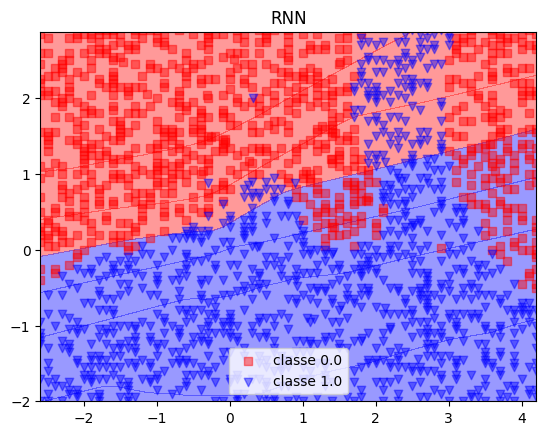

In [7]:
hist = model.fit(Xtrain, Ytrain, epochs=10, batch_size = 32)
from utils_intro_deep import plot_decision_2d
plot_decision_2d(Xtrain, Ytrain, model, resolution=0.02, titre="RNN")

* epochs: c'est le nombre de fois que le modèle parcourt l'ensemble du jeu de données d'entraînement (Xtrain). Chaque époque permet au modèle d'ajuster ses poids et biais sur la totalité des données ce qui permet d'améliorer l'apprentissage.  
* batch_size: c'est le nombre d'échantillons traités ensemble avant que les poids du modèle ne soient mis à jour. Cela permet de stabiliser l'entraînement et améliorer son efficacité.  
En résumé: Une epoch correspond au passage complet de l'ensemble des données à travers le modèle, réalisé en traitant successivement tous les batchs qui divisent ce jeu de données. En divisant en batchs, le modèle ajuste ses poids plusieurs fois par epoch. Il apprend donc beaucoup plus vite en corrigeant ses erreurs au fur et à mesure.

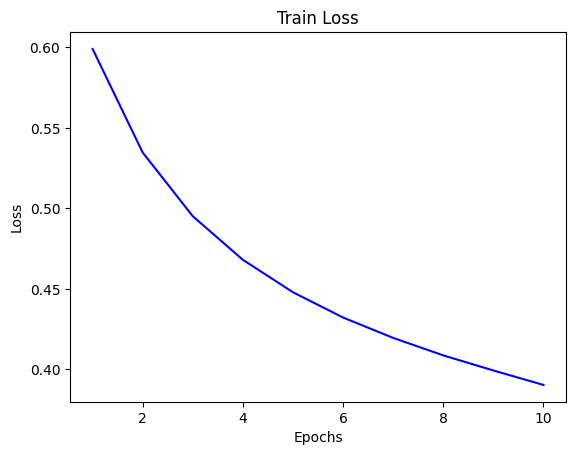

In [10]:
import matplotlib.pyplot as plt
plt.plot(range(1, len(hist.history["loss"])+1), hist.history["loss"], color="blue")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

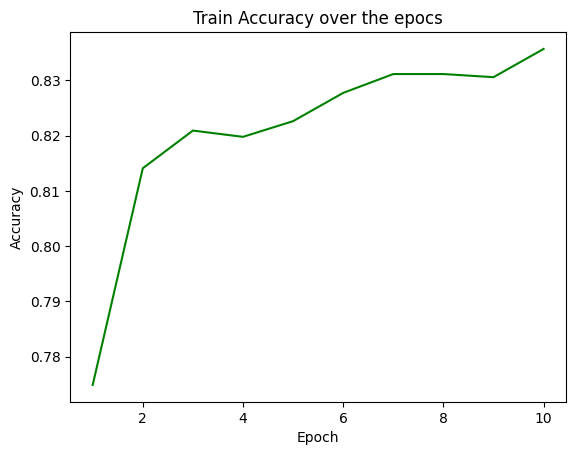

In [11]:
plt.plot(range(1, len(hist.history["accuracy"])+1), hist.history["accuracy"], color="green")
plt.title("Train Accuracy over the epocs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [12]:
score_test = model.evaluate(Xtrain, Ytrain)
print("\nLoss (test): %.3f" % score_test[0])
print("Accuracy (test): %.3f" % score_test[1])

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8351 - loss: 0.3858  

Loss (test): 0.386
Accuracy (test): 0.835


In [15]:
from keras.optimizers import Adam

def create_model(input_shape=(2,), nhu=64):
    model = Sequential([
        InputLayer(input_shape=input_shape),
        Dense(units=nhu, activation="relu"),
        Dense(units=1, activation="sigmoid")
    ])
    return model
tests = [
    {
        "name": "SGD - Base (10 epochs, batch 32)",
        "epochs": 10,
        "batch_size": 32,
        "optimizer": SGD(learning_rate=0.1, momentum=0.9),
    },
    {
        "name": "SGD - Long Train (20 epochs, batch 32)",
        "epochs": 20,
        "batch_size": 32,
        "optimizer": SGD(learning_rate=0.1, momentum=0.9),
    },
    {
        "name": "SGD - Small Batch (10 epochs, batch 8)",
        "epochs": 10,
        "batch_size": 8,
        "optimizer": SGD(learning_rate=0.1, momentum=0.9),
    },
    {
        "name": "Adam - New Optimizer (10 epochs, batch 32)",
        "epochs": 10,
        "batch_size": 32,
        "optimizer": Adam(learning_rate=0.001),
    }
]

results = []

for config in tests:
    print(f"**config: {config['name']} **")

    model = create_model()
    model.compile(
        optimizer=config["optimizer"],
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    hist = model.fit(
        Xtrain, Ytrain,
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        verbose=0
    )

    score_test = model.evaluate(Xtrain, Ytrain, verbose=0)

    final_loss = score_test[0]
    final_accuracy = score_test[1]

    print(f"Résultat pour {config['name']} :")
    print(f"Perte (Loss): {final_loss:.4f}")
    print(f"Précision (Accuracy): {final_accuracy:.4f}")

    results.append({
        "Test Name": config['name'],
        "Epochs": config['epochs'],
        "Batch Size": config['batch_size'],
        "Optimizer": config['optimizer'].__class__.__name__,
        "Final Loss": final_loss,
        "Final Accuracy": final_accuracy
    })

print("Synthèse des Résultats")
results_df = pd.DataFrame(results)
print(results_df.to_markdown(index=False))

**config: SGD - Base (10 epochs, batch 32) **
Résultat pour SGD - Base (10 epochs, batch 32) :
Perte (Loss): 0.1983
Précision (Accuracy): 0.8761
**config: SGD - Long Train (20 epochs, batch 32) **
Résultat pour SGD - Long Train (20 epochs, batch 32) :
Perte (Loss): 0.1580
Précision (Accuracy): 0.9267
**config: SGD - Small Batch (10 epochs, batch 8) **
Résultat pour SGD - Small Batch (10 epochs, batch 8) :
Perte (Loss): 0.2478
Précision (Accuracy): 0.8647
**config: Adam - New Optimizer (10 epochs, batch 32) **
Résultat pour Adam - New Optimizer (10 epochs, batch 32) :
Perte (Loss): 0.2686
Précision (Accuracy): 0.8624
Synthèse des Résultats
| Test Name                                  |   Epochs |   Batch Size | Optimizer   |   Final Loss |   Final Accuracy |
|:-------------------------------------------|---------:|-------------:|:------------|-------------:|-----------------:|
| SGD - Base (10 epochs, batch 32)           |       10 |           32 | SGD         |     0.198318 |         0

Le modèle SGD - Long Train (20 epochs, batch 32) donne le meilleur résultat.

## MLP for MNSIT

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Shape de x_train: (60000, 28, 28)
Shape de y_train: (60000,)
Shape de x_test: (10000, 28, 28)
Shape de y_test: (10000,)



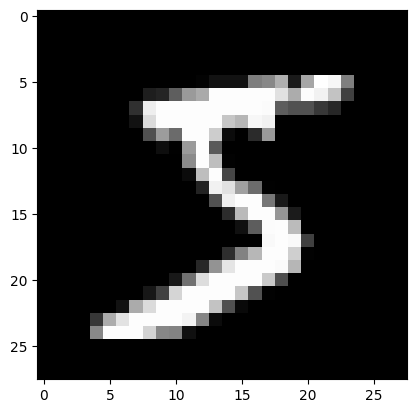

In [16]:
from keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(f"Shape de x_train: {x_train.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de x_test: {x_test.shape}")
print(f"Shape de y_test: {y_test.shape}\n")
plt.imshow(x_train[0], cmap='gray')
plt.show()

In [17]:
nb_pixels = x_train.shape[1] * x_train.shape[2]
x_train = x_train.reshape(x_train.shape[0], nb_pixels).astype('float32')
x_test = x_test.reshape(x_test.shape[0], nb_pixels).astype('float32')

# Normalisation (pixels de 0 à 255)
x_train /= 255
x_test /= 255

from keras.utils import to_categorical
nbclasses = len(np.unique(y_train))
y_train = to_categorical(y_train, nbclasses)
y_test = to_categorical(y_test, nbclasses)

In [18]:
model_mlp = Sequential([
    InputLayer(input_shape=(nb_pixels,)),
    Dense(units=800, activation='relu'),
    Dense(units=nbclasses, activation='softmax')
])

model_mlp.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 800)            │       628,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 636,010 (2.43 MB)

 Trainable params: 636,010 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

- Couche cachée : $(784 \text{ entrées} \times 800 \text{ neurones}) + 800 \text{ biais} = 628\,000$ paramètres.
- Couche de sortie : $(800 \text{ entrées} \times 10 \text{ neurones}) + 10 \text{ biais} = 8\,010$ paramètres.

In [19]:
model_mlp.compile(loss="categorical_crossentropy", optimizer=SGD(), metrics=["accuracy"])

In [20]:
history_mlp = model_mlp.fit(x_train, y_train, epochs=5, batch_size=128, verbose=1, validation_data=(x_test, y_test))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7750 - loss: 1.0548 - val_accuracy: 0.8731 - val_loss: 0.5781
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8768 - loss: 0.5087 - val_accuracy: 0.8948 - val_loss: 0.4230
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8923 - loss: 0.4126 - val_accuracy: 0.9053 - val_loss: 0.3657
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9011 - loss: 0.3683 - val_accuracy: 0.9114 - val_loss: 0.3346
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9066 - loss: 0.3409 - val_accuracy: 0.9161 - val_loss: 0.3135


In [21]:
score_test_mlp = model_mlp.evaluate(x_test, y_test, verbose=0)
print(f"\nLoss sur l'ensemble de test : {score_test_mlp[0]:.4f}")
print(f"Précision sur l'ensemble de test : {score_test_mlp[1]:.4f}")


Loss sur l'ensemble de test : 0.3135
Précision sur l'ensemble de test : 0.9161


In [22]:
model_mlp_2 = Sequential([
    InputLayer(input_shape=(nb_pixels,)),
    Dense(units=512, activation='relu'),
    Dense(units=256, activation='relu'),
    Dense(units=nbclasses, activation='softmax')
])

model_mlp_2.compile(loss="categorical_crossentropy", optimizer=SGD(), metrics=["accuracy"])

model_mlp_2.summary()

history_mlp_2 = model_mlp_2.fit(x_train, y_train, epochs=10, batch_size=128, verbose=1, validation_data=(x_test, y_test))

score_test_mlp_2 = model_mlp_2.evaluate(x_test, y_test, verbose=0)

print(f"\nLoss sur l'ensemble de test pour model_mlp_2: {score_test_mlp_2[0]:.4f}")
print(f"Précision sur l'ensemble de test pour model_mlp_2: {score_test_mlp_2[1]:.4f}")

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7500 - loss: 1.1006 - val_accuracy: 0.8779 - val_loss: 0.5179
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8858 - loss: 0.4435 - val_accuracy: 0.9034 - val_loss: 0.3678
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9035 - loss: 0.3533 - val_accuracy: 0.9155 - val_loss: 0.3161
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9122 - loss: 0.3136 - val_accuracy: 0.9212 - val_loss: 0.2866
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9186 - loss: 0.2879 - val_accuracy: 0.9249 - val_loss: 0.2669
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9235 - loss: 0.2684 - val_accuracy: 0.9322 - val_loss: 0.2510
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9279 - loss: 0.2524 - val_accuracy: 0.9343 - val_loss: 0.2366
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9325 - loss: 0.2388 - val_accuracy: 0.

## To go further

In [29]:
model_mlp.save("model_mlp.keras")

from keras.models import load_model
reconstructed_model_mlp = load_model("model_mlp.keras")

In [30]:
check = np.testing.assert_allclose(model_mlp.predict(x_test),
reconstructed_model_mlp.predict(x_test))
print(check)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
None


In [31]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=42)
nbepochs = 5
hist = model_mlp.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=
nbepochs, batch_size=32)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9128 - loss: 0.3105 - val_accuracy: 0.9185 - val_loss: 0.2916
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9223 - loss: 0.2755 - val_accuracy: 0.9262 - val_loss: 0.2648
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9294 - loss: 0.2502 - val_accuracy: 0.9315 - val_loss: 0.2442
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9361 - loss: 0.2301 - val_accuracy: 0.9369 - val_loss: 0.2276
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9401 - loss: 0.2133 - val_accuracy: 0.9410 - val_loss: 0.2147


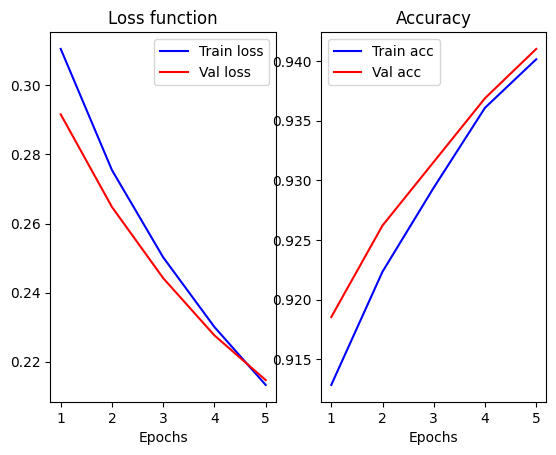

In [33]:
plt.figure(), plt.subplot(1,2,1)
plt.plot(range(1, nbepochs+1), hist.history["loss"], color="blue",
label="Train loss")
plt.plot(range(1, nbepochs+1), hist.history["val_loss"], color="red", label="Val loss")
plt.xlabel("Epochs"), plt.title("Loss function"), plt.legend(loc="best")
plt.subplot(1,2,2)
plt.plot(range(1, nbepochs+1), hist.history["accuracy"], color="blue",
label="Train acc")
plt.plot(range(1, nbepochs+1), hist.history["val_accuracy"], color="red",
label="Val acc")
plt.xlabel("Epochs"), plt.title("Accuracy"), plt.legend(loc="best");

- Les deux courbes descendent encore => Le modèle apprend toujours. Il faut continuer l'entraînement.
- La courbe de validation stagne => Le modèle a atteint son maximum. Il faut s'arrêter, c'est le point optimal.
- La courbe de validation remonte => Le modèle commence à mémoriser (overfitting). Il faut s'arrêter et revenir en arrière.

In [34]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

# EarlyStopping : Empêche le modèle de s'entraîner inutilement si la perte de validation ne diminue plus
early_stop = EarlyStopping(monitor="val_loss", patience=2, verbose=1)

# ModelCheckpoint : Garantit que même si le modèle commence à overfit lors de la dernière époque avant l'arrêt, 
# on conserve le fichier contenant la version la plus performante
checkpoint = ModelCheckpoint(
    filepath="best_model.keras", 
    monitor="val_loss", 
    save_best_only=True, 
    verbose=1
)

nbepochs = 10
hist = model_mlp.fit(
    x_train, y_train, 
    validation_split=0.25, 
    epochs=nbepochs, 
    batch_size=32, 
    shuffle=True, 
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
1039/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9432 - loss: 0.2051
Epoch 1: val_loss improved from None to 0.19309, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9439 - loss: 0.2011 - val_accuracy: 0.9470 - val_loss: 0.1931
Epoch 2/10
1049/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9457 - loss: 0.1976
Epoch 2: val_loss improved from 0.19309 to 0.18796, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9480 - loss: 0.1903 - val_accuracy: 0.9480 - val_loss: 0.1880
Epoch 3/10
1045/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9505 - loss: 0.1809
Epoch 3: val_loss improved from 0.18796 to 0.18145, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9505 - loss: 0.1806 - val_accurac

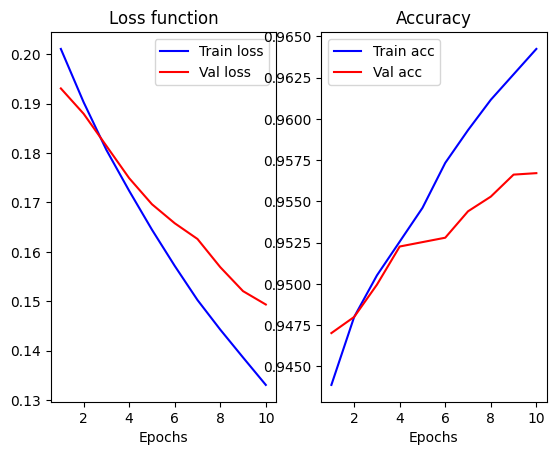

In [36]:
plt.figure(), plt.subplot(1,2,1)
plt.plot(range(1, nbepochs+1), hist.history["loss"], color="blue",
label="Train loss")
plt.plot(range(1, nbepochs+1), hist.history["val_loss"], color="red", label="Val loss")
plt.xlabel("Epochs"), plt.title("Loss function"), plt.legend(loc="best")
plt.subplot(1,2,2)
plt.plot(range(1, nbepochs+1), hist.history["accuracy"], color="blue",
label="Train acc")
plt.plot(range(1, nbepochs+1), hist.history["val_accuracy"], color="red",
label="Val acc")
plt.xlabel("Epochs"), plt.title("Accuracy"), plt.legend(loc="best");